# Build surface
###### Last updated 2024-04-24 (ASH)
###### Updated by ETU on 2024-05-06
This notebook walks though constructing a surface using a single long chain of bead type "A". This can be used to build homogenous surfaces in PIMMS.

### Approach
Broadly, the approach here is to:

1. Build a restart file where a single chain snakes along the bottom of the simulation box.
2. Save that dictionary as a restart file called `new_restart.pimms` (note this could be called literally anything but the `.pimms` extension seems sufficiently unique!)
3. Define a freezefile (`freezefile.in`) which freezes that one long 'surface' chain (which will be chainID 1 because it's the first and only chain in the restart file.
4. In the associated keyfile, run a simulation where we read in that restart file and freeze file.
5. Profit (?).

All the prep work is done in this directory, so you should be able to simply run

    pimms -k KEYFILE.kf

And a simulations with a surface will run. NOTE the surface is very large, so to make this computationally tractable we have the `SAVE_AT_END` keyword set to True, otherwise writing out to XTC file every few steps becomes very expensive. As it stands on an M3 Macbook Pro this simulation should take ~4-5 minutes to run.    

In [1]:
# import relevant packages
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## USER INPUTS ##
d = 50      # 50x50x50 size is used in this tutorial
num_chains = 50      # 50 chains are used in this tutorial
shrink = 3     # 'shrink' sets the diameter of the generated circle to be (d - shrink)
seqin = 'OGYGYGPYQPVPEQPLYPQPYQPQYQQYTF'    # string of 1-letter amino acids

In [3]:
# b is going to end up being the output dictionary
b = {}

# d defines the lattice size
d = 50 

# pos will be a list of 3-position lists defining [x,y,z] positions of
# each bead on the bottom surface
pos = []

# Start filling the grid, snaking up and down
count = 0
for col in range(d):
    if col % 2 == 0:
        
        # even columns go up
        for row in range(d):            
            pos.append([row,col,0])            
    else:
        # odd columns go down
        for row in range(d-1, -1, -1):            
            pos.append([row,col,0])      

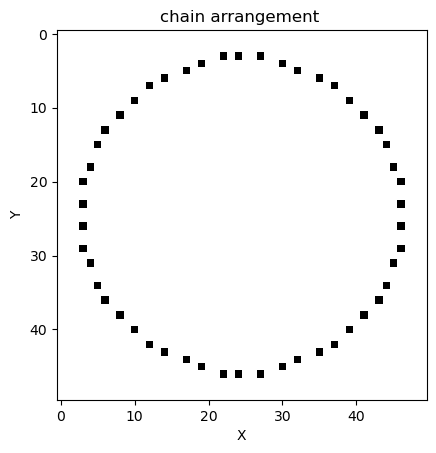

In [4]:
## the function 'generate_symmetric_pattern_coordinates' takes the inputs:
#    grid_size (int) - this should be the same as 'd' box side length
#    num_cells (int) - equal to the # of chains to be simulated (not including surface 'chain')
#    edge_buffer (int) - the number of cells on either side of the circle perimeter
#
# the result of the function is a list of (x,y) coordinates arranged in a circle (see plot)

def generate_symmetric_pattern_coordinates(grid_size, num_cells, edge_buffer):
    grid_center = (grid_size - 1) / 2  # Center of the grid (assuming 0-indexed)
    radius = min(grid_center - edge_buffer, num_cells // 2)  # Maximum radius to ensure symmetric pattern

    # Generate angles evenly spaced around a circle
    angles = np.linspace(0, 2 * np.pi, num_cells, endpoint=False)

    # Calculate coordinates of each cell based on polar coordinates
    x_coords = np.round(grid_center + radius * np.cos(angles)).astype(int)
    y_coords = np.round(grid_center + radius * np.sin(angles)).astype(int)

    # Return coordinates as a list of tuples
    return [(x, y) for x, y in zip(x_coords, y_coords)]

# Generate filled cell coordinates
grid_size = d
num_cells = num_chains
edge_buffer = shrink
filled_cell_coordinates = generate_symmetric_pattern_coordinates(grid_size, num_cells, edge_buffer)

# Create a 50x50 grid
grid = np.zeros((grid_size, grid_size))

# Mark the filled cell locations in the grid
for x, y in filled_cell_coordinates:
    grid[x, y] = 1

# Plot the grid
plt.imshow(grid, cmap='binary')
plt.title('chain arrangement ')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [5]:
# assuming many copies of a single chain sequence
sequence = str(seqin)

In [6]:
## the function 'generate_z_coordinates' uses the circle coordinate list generated above
#  and creates a new list of (x,y,z) coordinates based on the length of the chain specified above
#     filled_cell_coordinates (list) - the list of (x,y) coordinates returned by 'generate_symmetric_pattern_coordinates'
#     num_z_cells (int) - is the length of the 'sequence' string

def generate_z_coordinates(filled_cell_coordinates, num_z_cells):
    z_coordinates = []
    for x, y in filled_cell_coordinates:
        z_coordinates.extend([[x, y, z] for z in range(1, num_z_cells + 1)])
    return z_coordinates

# Generate z coordinates for each (x, y) location starting at z=1
num_z_cells = len(sequence)  # Number of cells vertically above each location
z_coordinates = generate_z_coordinates(filled_cell_coordinates, num_z_cells)

#print(z_coordinates)
#print(num_z_cells)

In [7]:
# now we define the required components of PIMMS restart file

## define 1 chain (REMEMBER chainID must start at 1)
#  pos = positions
#  'J'*len(pos) = string of As that describes the 'sequence'
#   0 = the chainType ID which should be the same for chains of the same sequence (although strictly speaking does not have to be...)

# this part creates dictionary 'b' 
b['CHAINS'] = {}
b['CHAINS'][1] = [pos, 'J'*len(pos), 0]

# box dimensions
b['DIMENSIONS'] = [d,d,d]

# energy but this does not actually matter and is not actually used
b['ENERGY'] = 0

# defines mode of simulation (must be true for surface sims!)
b['HARDWALL'] = True


In [7]:
# Convert the coordinates to tuples
coordinates_list = [tuple(coord) for coord in z_coordinates]

# Organize the coordinates into groups based on unique (x, y) pairs
unique_coordinate_groups = {}
for x, y, z in coordinates_list:
    unique_coordinate_groups.setdefault((x, y), []).append(z)

In [8]:
# Create a list to store lists of xyz coordinates for each unique coordinate group
# a 'unique_coordinate_group' is simply all same (x,y) pairs grouped together
coordinate_groups_list = []

# Iterate over each unique (x, y) pair and its associated z-coordinates
for (x, y), z_coordinates in unique_coordinate_groups.items():
    # Create a list to store xyz coordinates for the current unique coordinate group
    xyz_coordinates = []
    # Append each xyz coordinate to the list
    for z in z_coordinates:
        xyz_coordinates.append([x, y, z])
    # Append the list of xyz coordinates to the main list
    coordinate_groups_list.append(xyz_coordinates)


NameError: name 'unique_coordinate_groups' is not defined

In [9]:
## chain index 1 is the surface chain, so we must start chain idxing at 2
curr_chain_idx = 2

# now build upon the dictionary b created earlier, but iterating the chain idx and (x,y) location
#    each loop iterations reflects one (x,y) location where a chain is to be built vertically
for i in range(len(filled_cell_coordinates)):
    templist = []
    for group in coordinate_groups_list[i]:
        templist.append(group)
    
    ## at this point, 'templist' contains a list of coordinates [x1, y1, 1]... [x1, y1, num_z_cells]
    #  in the next iteration, 'templist' will contain [x2, y2, 1]... [x2, y2, num_z_cells]
    #  and so on for each point on the circle
    #  the line below maps each residue in the sequence to a unique z coordinate in order (ie., z = 1, res = O; z = 2, res = G; etc.)
    b['CHAINS'][curr_chain_idx] = [templist, sequence, 1]
    curr_chain_idx = curr_chain_idx + 1
    

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51


In [11]:
## write out restart file as binary
#  any filename is fine with the extension .pimms
with open('surface_restart_attached.pimms', 'wb') as handle:
    pickle.dump(b, handle)
